# Affine transforms

clesperanto ships a set of ready-to-use spatial transform operations - `rotate()`, `translate()`,
`scale()`, `rigid_transform()` - as well as a more generic, matrix-based `affine_transform()` for
arbitrary combinations of rotation, translation, scaling and shearing.

This notebook is organized in three parts:

1. **Basic transforms**: rotation, translation, scaling and rigid transform.
2. **Affine transforms**: building and applying a 4x4 transformation matrix with
   `cle.transform.AffineTransform`, including automatic output resizing.
3. **Interoperability**: reusing a `scikit-image` `AffineTransform` matrix directly with
   pyclesperanto, and comparing nearest-neighbor vs. linear interpolation.

> See [Affine transformation](https://en.wikipedia.org/wiki/Affine_transformation) and
> [Transformation matrix](https://en.wikipedia.org/wiki/Transformation_matrix) on Wikipedia for
> background on the math.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

import pyclesperanto as cle

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load example data

We use a 3D MRI stack for this demo. All transform operations below work identically in 2D and
3D; we display maximum-intensity projections along the z-axis for the 3D examples.

shape (z, y, x): (120, 160, 160)


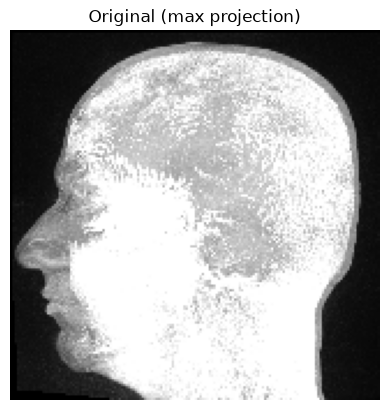

In [2]:
input_image = cle.push(imread("../data/Haase_MRT_tfl3d1.tif"))
print("shape (z, y, x):", input_image.shape)

plt.imshow(cle.pull(input_image).max(axis=0), cmap="gray")
plt.title("Original (max projection)")
plt.axis("off")
plt.show()

## 1. Basic transforms

### 1.1 Rotation

`cle.rotate()` rotates an image around one or more axes. Angles are given **in degrees**, one per
axis (`angle_x`, `angle_y`, `angle_z`).

The `centered` parameter controls the origin of the rotation:
- `centered=True` (default): the image is rotated around its **center**.
- `centered=False`: the image is rotated around the **origin** (pixel (0, 0)), which also shifts
  the content.

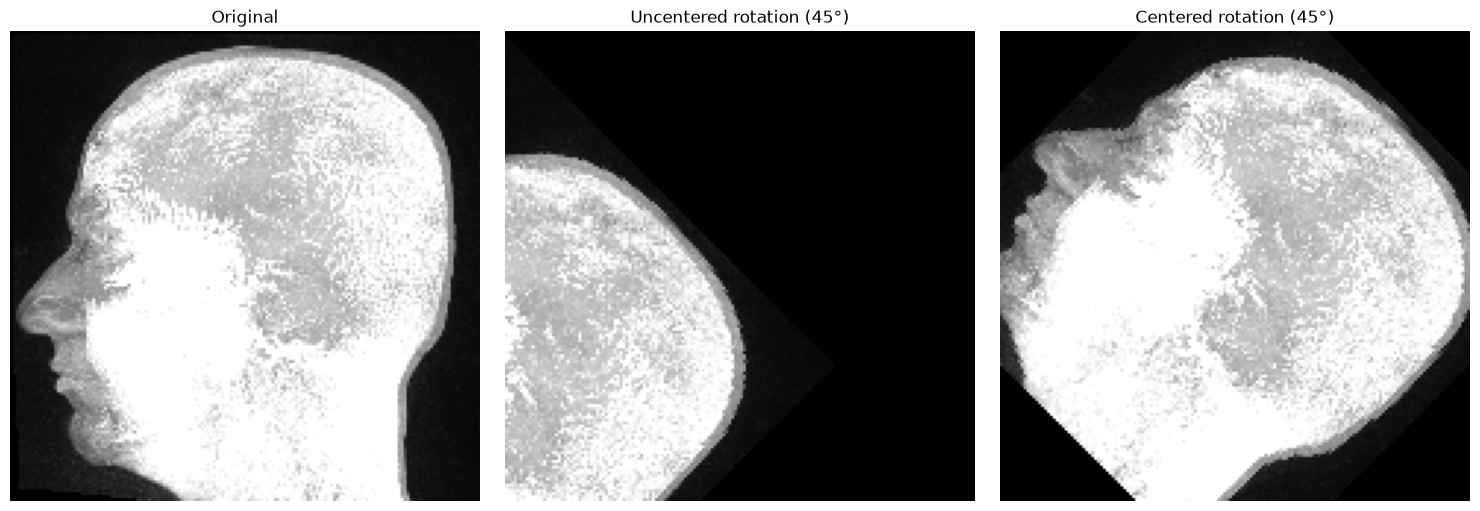

In [3]:
rotated_centered = cle.rotate(input_image, angle_z=45)
rotated_uncentered = cle.rotate(input_image, angle_z=45, centered=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(
    axes,
    [input_image, rotated_uncentered, rotated_centered],
    ["Original", "Uncentered rotation (45°)", "Centered rotation (45°)"],
):
    ax.imshow(cle.pull(img).max(axis=0), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1.2 Translation

`cle.translate()` shifts the image content by a given number of pixels along each axis.

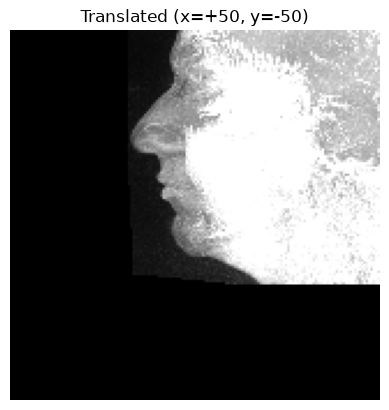

In [4]:
translated = cle.translate(input_image, translate_x=50, translate_y=-50)

plt.imshow(cle.pull(translated).max(axis=0), cmap="gray")
plt.title("Translated (x=+50, y=-50)")
plt.axis("off")
plt.show()

### 1.3 Scaling and automatic output resizing

`cle.scale()` scales the image by a factor per axis. Scaling can grow the content beyond the
original canvas; passing `resize=True` automatically computes an output image large enough to
hold the scaled content, instead of cropping it.

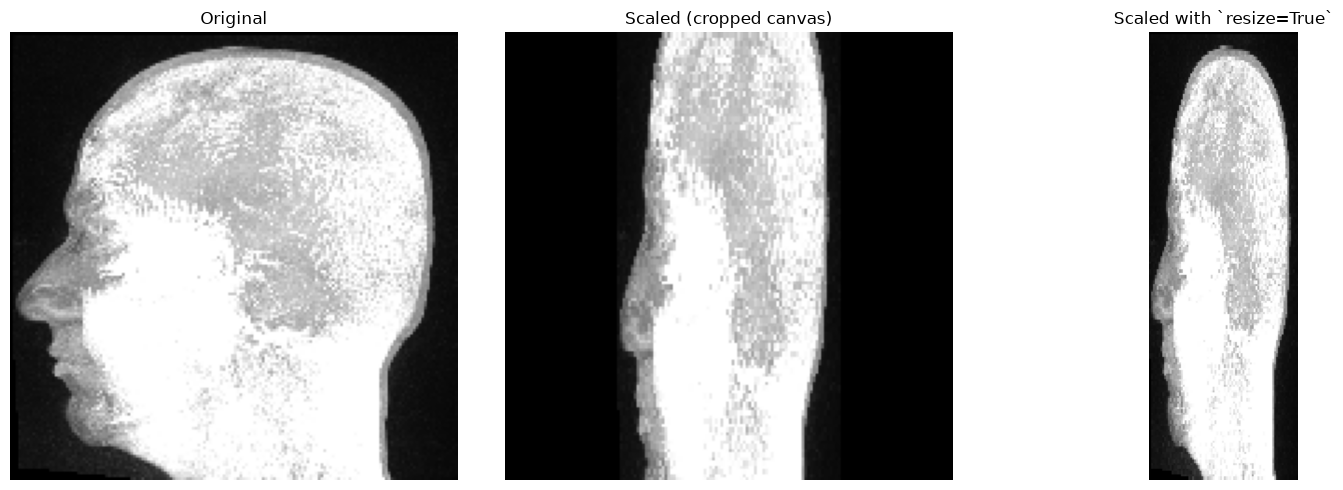

In [5]:
scaled = cle.scale(input_image, factor_x=0.5, factor_y=1.5)
scaled_resized = cle.scale(input_image, factor_x=0.5, factor_y=1.5, resize=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(
    axes,
    [input_image, scaled, scaled_resized],
    ["Original", "Scaled (cropped canvas)", "Scaled with `resize=True`"],
):
    ax.imshow(cle.pull(img).max(axis=0), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1.4 Rigid transform

A [rigid transformation](https://en.wikipedia.org/wiki/Rigid_transformation) combines a
translation and a rotation into a single operation without deforming the image (no scaling or
shearing). This is convenient, for example, to register two images that only differ by their
position and orientation.

Note the unit difference with `rotate()`: `rigid_transform()` expects its rotation angles **in
radians**, so degrees must be converted first with `np.deg2rad()`.

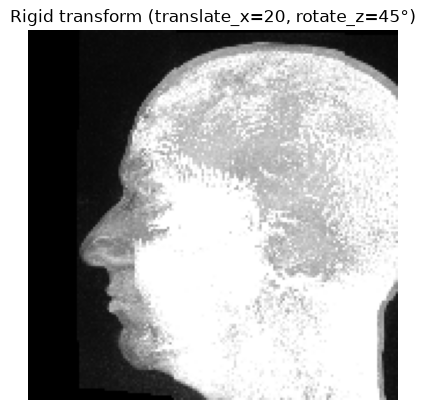

In [6]:
rigid_transformed = cle.rigid_transform(
    input_image, translate_x=20, angle_z=np.deg2rad(45)
)

plt.imshow(cle.pull(rigid_transformed).max(axis=0), cmap="gray")
plt.title("Rigid transform (translate_x=20, rotate_z=45°)")
plt.axis("off")
plt.show()

## 2. Affine transforms

Rotation, translation, scaling and shearing can all be expressed as a single 4x4
[affine transformation matrix](https://en.wikipedia.org/wiki/Transformation_matrix). The generic
`cle.transform.affine_transform()` operation applies such a matrix to an image, which is more
powerful (and more low-level) than the dedicated operations seen above.

The matrix is wrapped in a `cle.transform.AffineTransform` object, which can be built:
- directly from a 4x4 (or 3x3, for 2D) numpy array, or
- incrementally, by chaining transformation methods (`rotate`, `translate`, `scale`, ...).

### 2.1 From an explicit matrix

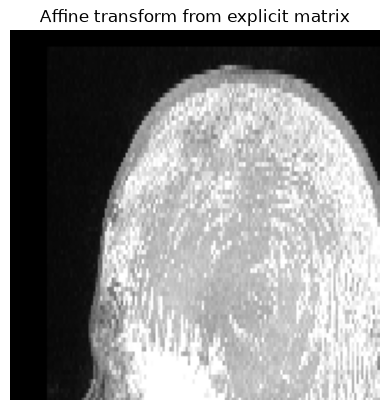

In [7]:
transform_matrix = np.asarray([
    [1, 0, 0, 15],
    [0, 2, 0, 5],
    [0, 0, 0.5, 0],
    [0, 0, 0, 1],
])

matrix = cle.transform.AffineTransform(transform_matrix)
transformed_image = cle.transform.affine_transform(input_image, transform_matrix=matrix)

plt.imshow(cle.pull(transformed_image).max(axis=0), cmap="gray")
plt.title("Affine transform from explicit matrix")
plt.axis("off")
plt.show()

### 2.2 Building a matrix incrementally

Instead of writing the matrix by hand, transformations can be chained on an `AffineTransform`
object, which is often more readable. Each call updates the underlying matrix in place.

In [8]:
matrix = cle.transform.AffineTransform()
matrix.rotate(axis=2, angle_deg=45)
matrix.translate(translate_x=20, translate_y=-20, translate_z=0)

print(matrix)

AffineTransform([[0.707107, -0.707107, 0, 20],
 [0.707107, 0.707107, 0, -20],
 [0, 0, 1, 0],
 [0, 0, 0, 1]])


### 2.3 Automatic output shape

As with `scale()`, applying an affine transform can move content outside of the original canvas.
`resize=True` handles this automatically; `cle.transform.compute_output_shape_from_transform()`
lets you inspect the resulting output shape (and the corresponding adjusted matrix) ahead of
time.

input shape:  (120, 160, 160)
output shape: (120, 226, 226)


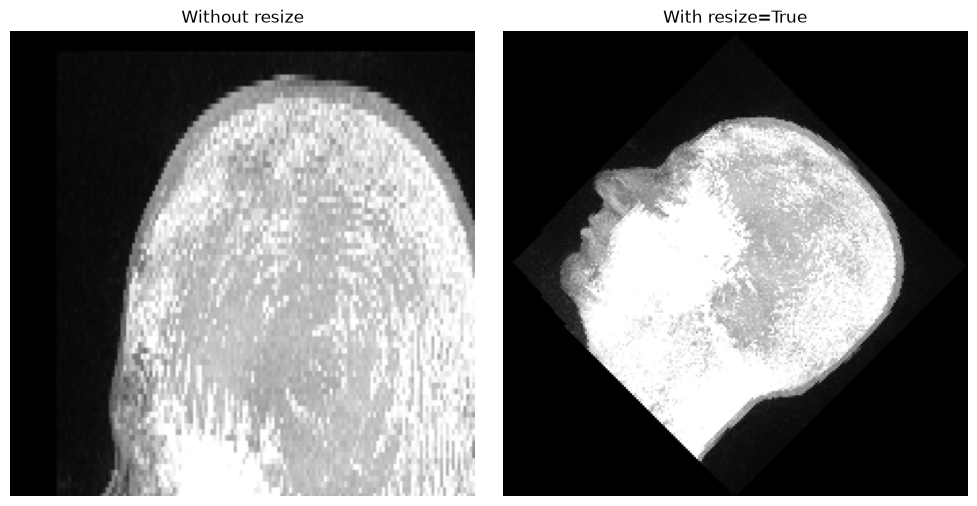

In [9]:
output_shape, adjusted_matrix = cle.transform.compute_output_shape_from_transform(
    input_image.shape, matrix
)
print("input shape: ", input_image.shape)
print("output shape:", output_shape)

transformed_resized = cle.transform.affine_transform(
    input_image, transform_matrix=matrix, resize=True
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cle.pull(transformed_image).max(axis=0), cmap="gray")
axes[0].set_title("Without resize")
axes[1].imshow(cle.pull(transformed_resized).max(axis=0), cmap="gray")
axes[1].set_title("With resize=True")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Interoperability with scikit-image

pyclesperanto's affine matrix follows the same convention as `skimage.transform.AffineTransform`
(a homogeneous matrix acting on `(x, y, 1)` coordinates), so a matrix built with scikit-image can
be passed directly to `cle.affine_transform()` - no conversion needed. This makes it easy to
prototype a transform with scikit-image and then run it on the GPU with pyclesperanto.

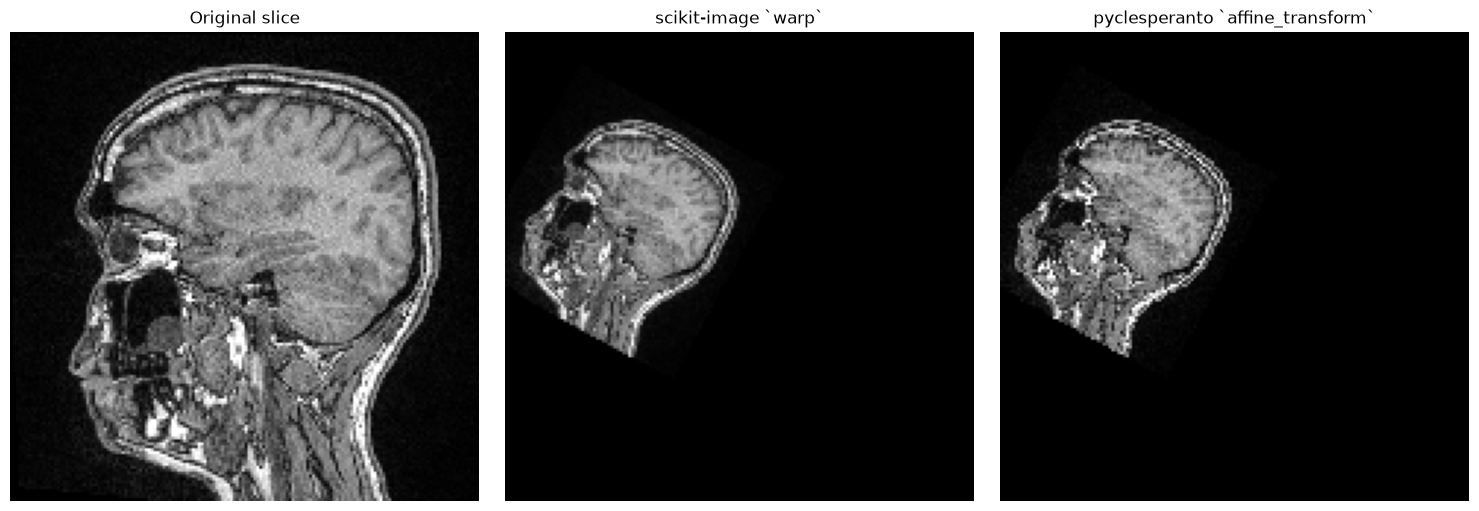

In [10]:
from skimage import transform as sk_transform

sk_affine = sk_transform.AffineTransform(scale=0.5, translation=(25, 10), rotation=0.5)

image_2d = cle.pull(input_image)[80]
warped_skimage = sk_transform.warp(image_2d, sk_affine.inverse)
warped_gpu = cle.affine_transform(image_2d, transform_matrix=sk_affine.params)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(
    axes,
    [image_2d, warped_skimage, cle.pull(warped_gpu)],
    ["Original slice", "scikit-image `warp`", "pyclesperanto `affine_transform`"],
):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Interpolation: nearest-neighbor vs. linear

Transform operations in pyclesperanto support two interpolation modes:
- **nearest-neighbor** (`interpolate=False`, default): fast, but can produce blocky/aliased
  results, especially when up-scaling.
- **linear** (`interpolate=True`): bilinear in 2D / trilinear in 3D, relies on hardware
  interpolation support (not available on all devices), and produces smoother results.

The example below applies a stronger transform to make the difference more visible.

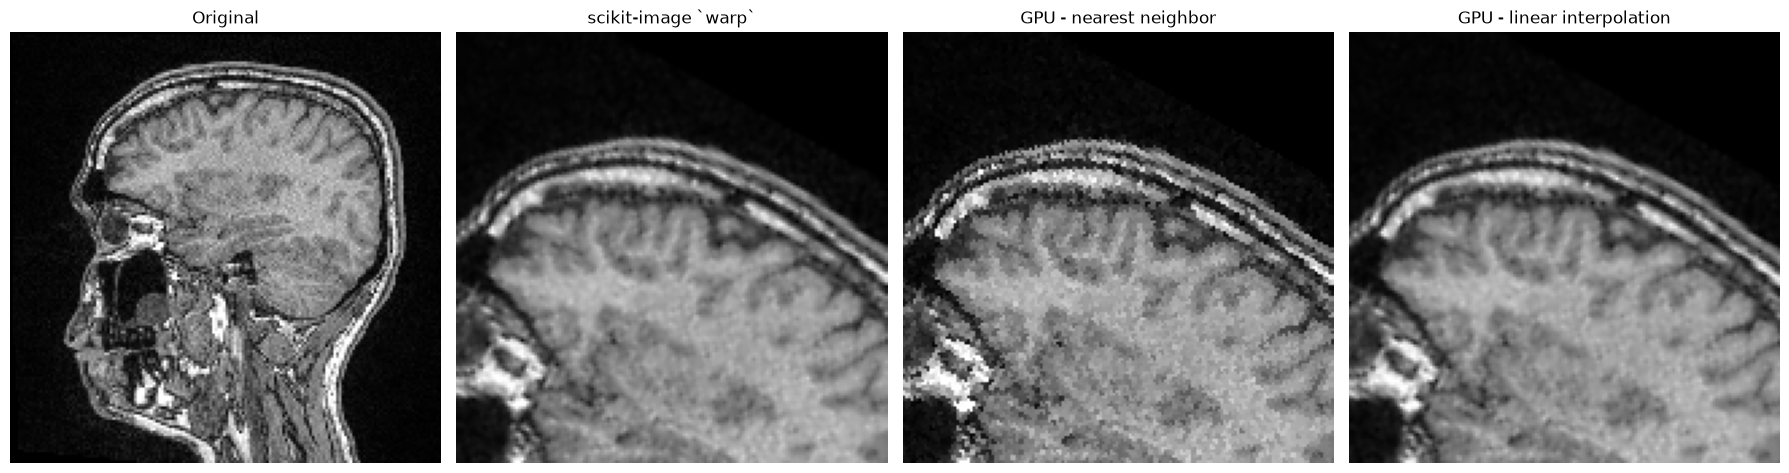

In [11]:
sk_affine_strong = sk_transform.AffineTransform(scale=1.75, translation=(5, -30), rotation=0.5)

image_2d = cle.pull(input_image)[80]
warped_skimage = sk_transform.warp(image_2d, sk_affine_strong.inverse)
warped_gpu_nearest = cle.affine_transform(
    image_2d, transform_matrix=sk_affine_strong.params, interpolate=False
)
warped_gpu_linear = cle.affine_transform(
    image_2d, transform_matrix=sk_affine_strong.params, interpolate=True
)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img, title in zip(
    axes,
    [image_2d, warped_skimage, cle.pull(warped_gpu_nearest), cle.pull(warped_gpu_linear)],
    ["Original", "scikit-image `warp`", "GPU - nearest neighbor", "GPU - linear interpolation"],
):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()